Batarya Ömür Tahmini Projesi (Battery Aging Prediction Project)

Daha iyi veri analizi için XGBoost ve LightGBM modelleri oluşturma ve testler yapma (Building XGBoost and LightGBM models for better data analysis and testing).

1. Gerekli kütüphaneleri koda ekledim (Added essential libraries to the code).

In [ ]:
#Got the essential libraries
import h5py
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import tqdm
import optuna
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, GroupShuffleSplit , GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

2. Analize hazır veriyi h5 dosyasından alıp, bu veriler ile bir XGBoost (Extreme Gradient Boosting) regresyon modeli eğittim,hiperparametre optimizasyonu yaptım ve test ettim
(Got the data ready for analysis from the h5 file, trained an XGBoost (Extreme Gradient Boosting) regression model with this data, did hyperparameter optimization and tested it).

In [6]:
#Defined features,target and battery groups matrices
Features_list = []
Target_list = []
Groups_list = []

#Defined error rates for model statistics
fold_rmse_scores = []
fold_mae_scores = []

fold_rmse_opt_scores = []
fold_mae_opt_scores = []

#Defining matrices to collect all test and predictions for comparison later
all_y_test = []
all_y_prediction_opt = []

#Defined matrices to collect all coefficients of the model
all_fold_feature_importances = []
all_fold_opt_feature_importances = []

#Opened the h5 file with features and target data 
with h5py.File("FastCharge__Features_Target.h5", "r") as h5f:
    first_battery = list(h5f.keys())[0]
    feature_names = h5f[first_battery]['Features'].attrs['Names']
    print("Features Used in the Model:")
    print(feature_names)

    #Got the features and target data, and grouped them under same battery name
    batteries = list(h5f.keys())
    for battery_index,battery_name in enumerate(batteries):
        features = h5f[battery_name]['Features'][:]
        target = h5f[battery_name]['Target'][:]
        
        Features_list.append(features)
        Target_list.append(target)

        num_cycles = features.shape[0]
        Groups_list.append(np.full(num_cycles, battery_index))

    #Combining all feature,target,groups values in one for each
    Features = np.vstack(Features_list)
    Target = np.concatenate(Target_list)
    Groups = np.concatenate(Groups_list)

    #Defined K-Fold Group for 5 different train-test configurations
    gkf = GroupKFold(n_splits=5)

    #Splitted the batteries with indexes gotten from K-Fold Group
    for fold, (train_index, test_index) in enumerate(gkf.split(Features, Target, Groups)):
        print(f"--- FOLD {fold+1} ---")

        X_train, X_test = Features[train_index], Features[test_index]
        y_train, y_test = Target[train_index], Target[test_index]

        #Built a base model with pipeline
        base_pipeline = Pipeline([
            ('imputer',SimpleImputer(strategy='median')),
            ('scaler',MinMaxScaler()),
            ('model',XGBRegressor(n_estimators=1500, learning_rate = 0.1, objective='reg:squarederror',random_state=42, n_jobs=-1))
        ])

        #Trained the base model for future comparison
        print("XGBoost is training...")
        model = base_pipeline.fit(X_train, y_train)

        #Built another model with pipeline for hyperparameter optimization
        opt_pipeline = Pipeline([
            ('imputer',SimpleImputer(strategy='median')),
            ('scaler',MinMaxScaler()),
            ('model',XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1))
        ])
        
        #Set hyperparameter options for grid search
        param_grid = {
            'model__n_estimators': [3500],
            'model__max_depth': [3],
            'model__gamma': [0],
            'model__reg_lambda': [1, 5],
            'model__learning_rate' : [0.1, 0.2],
            'model__colsample_bytree' : [0.9,1.0]
        }

        #Defined the grid search for optimization with GroupKFold split
        grid_search = GridSearchCV(
            estimator=opt_pipeline,
            param_grid=param_grid,
            cv=GroupKFold(n_splits=3),
            scoring='neg_mean_squared_error',
            n_jobs=-1
        )
        
        #Built another model with optimized hyperparameters and trained it for future comparison
        grid_search.fit(X_train, y_train, groups=Groups[train_index])
        model_opt = grid_search.best_estimator_
        print(f"Best parameters: {grid_search.best_params_}")
        
        #Inspected the feature importances
        feature_importances = model[-1].feature_importances_
        opt_feature_importances = model_opt[-1].feature_importances_
        print("Feature Importances:", np.round(feature_importances, 4))
        print("Feature Importances:", np.round(opt_feature_importances, 4))

        #Filled matrices with coefficients for later
        all_fold_feature_importances.append(feature_importances)
        all_fold_opt_feature_importances.append(opt_feature_importances)

        #Did the prediction and calculated the error rates
        y_prediction = model.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, y_prediction))
        mae = mean_absolute_error(y_test, y_prediction)

        y_prediction_opt = model_opt.predict(X_test)
        rmse_opt = np.sqrt(mean_squared_error(y_test, y_prediction_opt))
        mae_opt = mean_absolute_error(y_test, y_prediction_opt)
        
        #Added error rates to the matrices
        fold_rmse_scores.append(rmse)
        fold_mae_scores.append(mae)

        fold_rmse_opt_scores.append(rmse_opt)
        fold_mae_opt_scores.append(mae_opt)

        #Filled matrices with test and predictions for comparison later
        all_y_test.extend(y_test)
        all_y_prediction_opt.extend(y_prediction_opt)
                
        print(f"RMSE           : {rmse:.4f} | MAE           : {mae:.4f}")
        print(f"RMSE(Optimized): {rmse_opt:.4f} | MAE(Optimized): {mae_opt:.4f}")

    #Calculating mean and std values of each coefficient
    mean_feature_importances = np.mean(all_fold_feature_importances, axis=0)
    mean_opt_feature_importances = np.mean(all_fold_opt_feature_importances, axis=0)
    std_opt_feature_importances = np.std(all_fold_opt_feature_importances, axis=0)

    #Printed the results
    print("\n" + "="*50)
    print("XGBOOST REGRESSOR 5-FOLD ERROR RATE RESULTS:")
    print(f"Mean RMSE           : {np.mean(fold_rmse_scores):.4f}")
    print(f"Mean MAE            : {np.mean(fold_mae_scores):.4f}")
    print(f"Mean RMSE(Optimized): {np.mean(fold_rmse_opt_scores):.4f}")
    print(f"Mean MAE(Optimized) : {np.mean(fold_mae_opt_scores):.4f}")

Features Used in the Model:
['Internal_Resistance' 'Temperature_Variance' 'dQ/dV_Kurtosis'
 'dQ/dV_Skewness' 'dQ/dV_Peakheight' 'dQ/dV_Variance_log']
--- FOLD 1 ---
XGBoost is training...
Best parameters: {'model__colsample_bytree': 0.9, 'model__gamma': 0, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 3500, 'model__reg_lambda': 5}
Feature Importances: [0.0064 0.0022 0.019  0.0431 0.0147 0.9146]
Feature Importances: [0.007  0.0026 0.0384 0.0333 0.3011 0.6175]
RMSE           : 0.0057 | MAE           : 0.0037
RMSE(Optimized): 0.0049 | MAE(Optimized): 0.0032
--- FOLD 2 ---
XGBoost is training...
Best parameters: {'model__colsample_bytree': 1.0, 'model__gamma': 0, 'model__learning_rate': 0.2, 'model__max_depth': 3, 'model__n_estimators': 3500, 'model__reg_lambda': 5}
Feature Importances: [0.0064 0.0021 0.0136 0.0525 0.0181 0.9073]
Feature Importances: [0.0098 0.0039 0.0115 0.0571 0.0173 0.9004]
RMSE           : 0.0046 | MAE           : 0.0031
RMSE(Optimized): 0.

3. Modelin optimizasyon sonrası tüm train-test konfigürasyonlarının sonuçlarını kullanarak grafikler çizdirdim
(Plotted graphs with the results from last train-test configuration of the model after optimization).

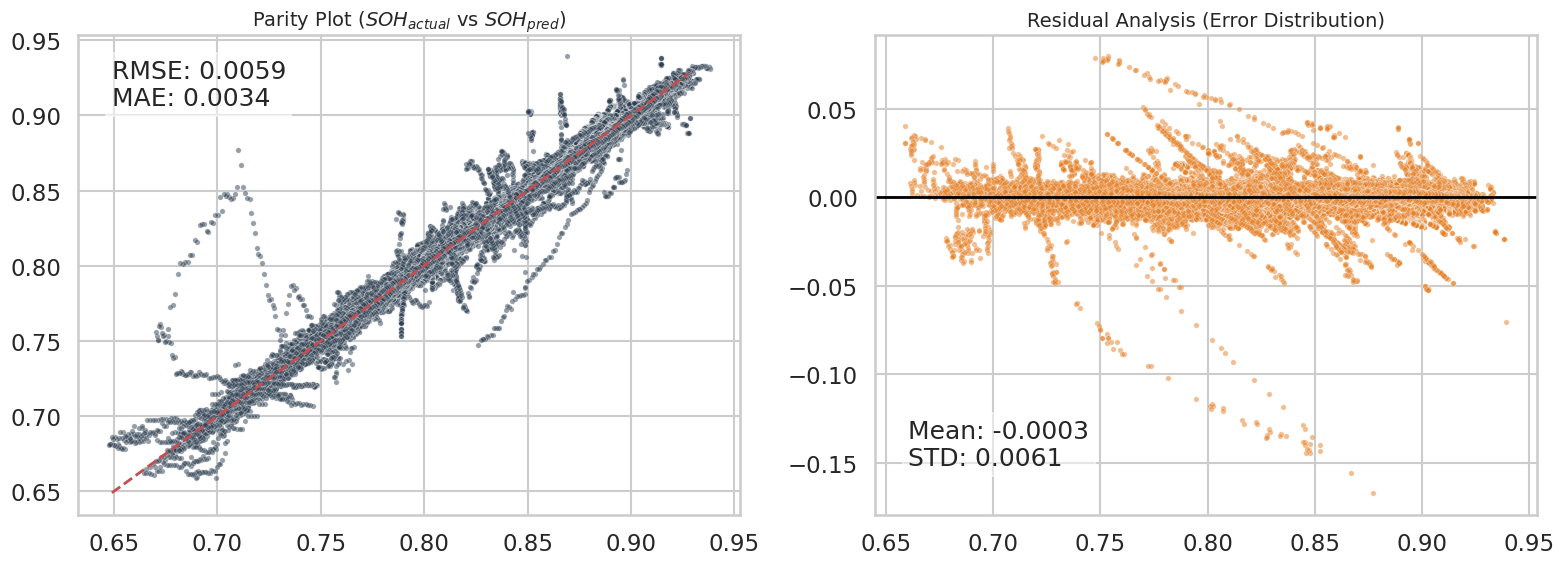

In [7]:
#Set the seaborn theme
sns.set_theme(style="whitegrid", context="talk")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#Plotted the parity(Real vs Predicted)
sns.scatterplot(x=all_y_test, y=all_y_prediction_opt, alpha=0.5, color="#2c3e50", s=15, ax=axes[0])
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title(r'Parity Plot ($SOH_{actual}$ vs $SOH_{pred}$)', fontsize=14)


#Plotted the residuals ()
residuals = np.array(all_y_test) - np.array(all_y_prediction_opt)
sns.scatterplot(x=all_y_prediction_opt, y=residuals, alpha=0.5, color="#e67e22", s=15, ax=axes[1])
axes[1].axhline(0, color='black', linestyle='-', lw=2)
axes[1].set_title('Residual Analysis (Error Distribution)', fontsize=14)
axes[0].text(0.05, 0.95, f'RMSE: {np.mean(fold_rmse_opt_scores):.4f}\nMAE: {np.mean(fold_mae_opt_scores):.4f}',
transform=axes[0].transAxes, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))
axes[1].text(0.05, 0.2, f'Mean: {np.mean(residuals):.4f}\nSTD: {np.std(residuals):.4f}', 
transform=axes[1].transAxes, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))

#Printed the graph
plt.tight_layout()
plt.show()

4. Hiperparametre optimizasyonu öncesi ve sonrası XGBoost modelinin öznitelik önemlerini karşılaştırdım
(Compared the feature importances of the XGBoost model for before-after hyperparameter optimization)

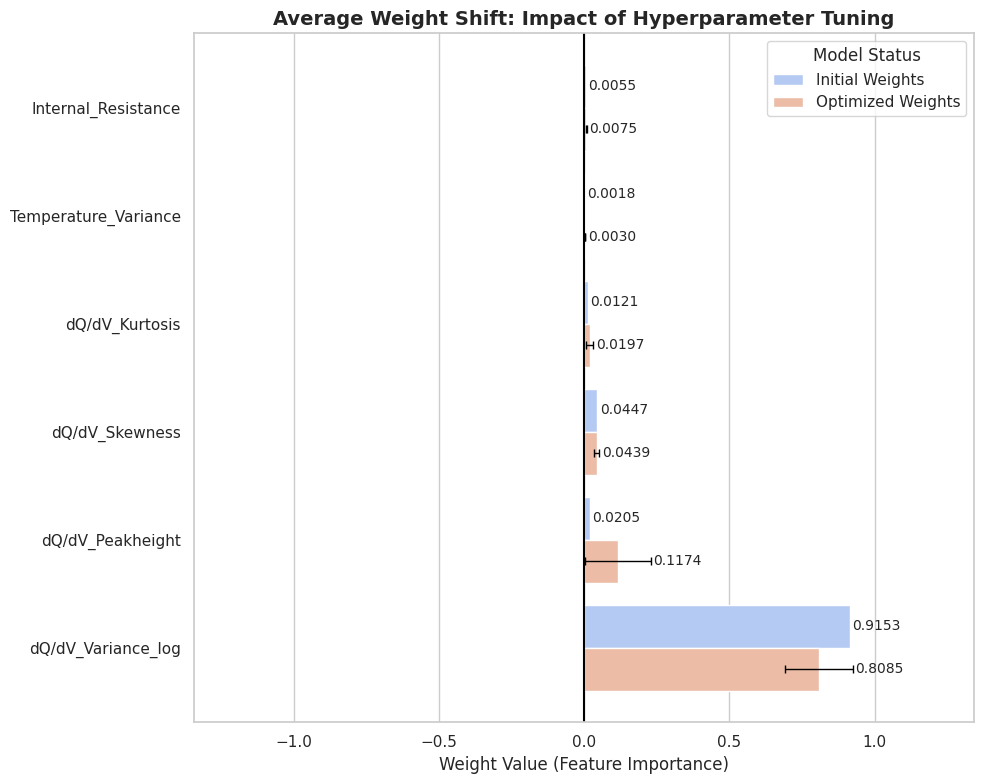

In [8]:
#Defined the coefficient data for features
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Initial Weights': mean_feature_importances,
    'Optimized Weights': mean_opt_feature_importances
}).melt(id_vars='Feature', var_name='Model Status', value_name='Weight Value')

#Defined the size of the plot
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

#Plotted a bar graph
ax = sns.barplot(
    data=coef_df, 
    y='Feature',      
    x='Weight Value', 
    hue='Model Status', 
    palette='coolwarm'
)

#Adjusted the graph for small values
max_val = coef_df['Weight Value'].abs().max()
max_std = np.max(std_opt_feature_importances)
plt.xlim(-(max_val + max_std) * 1.3, (max_val + max_std) * 1.3) 

#Set up the title and labels
plt.title('Average Weight Shift: Impact of Hyperparameter Tuning', fontweight='bold', fontsize=14)
plt.xlabel('Weight Value (Feature Importance)', fontsize=12)
plt.ylabel('') 
plt.axvline(0, color='black', lw=1.5) 

#Wrote the coefficient values on the graph
for i, p in enumerate(ax.patches):
    width = p.get_width()
    if abs(width) > 1e-6:
        #Calculated the offset to avoid overlap with error bars
        feature_idx = i % len(feature_names)
        current_std = std_opt_feature_importances[feature_idx] if i >= len(feature_names) else 0
        text_offset = current_std + (max_val * 0.1)
        
        ax.annotate(f'{width:.4f}', 
                    (width + (text_offset if width > 0 else -text_offset), p.get_y() + p.get_height() / 2.),
                    ha = 'center', va = 'center', 
                    fontsize=10)
        
        #Added error bars for Optimized Weights and defined a label for legend
        if i >= len(feature_names): 
            eb = plt.errorbar(
                x=width, 
                y=p.get_y() + p.get_height() / 2., 
                xerr=current_std, 
                fmt='none', c='black', capsize=3, elinewidth=1,
                label='Cross-Val Std. Dev.' if i == len(ax.patches)-1 else ""
            )

#Printed the graph
plt.legend(title='Model Status', loc='best')
plt.tight_layout()
plt.show()

5. Batalyalar özelinde XGBoost modelinin hata oranlarını hesapladım, en yüksek ve en düşük hata oranına sahip piller için model performansını grafiklerle karşılaştırdım
(Calculated the error rates or XGBoost model for individual batteries, compared the model performance with graphics on batteries with highest and lowest error rates).

Rank  | Best Batteries (Low Error)         | Worst Batteries (High Error)  
---------------------------------------------------------------------------
#1    | FastCharge_000007_CH24_st (0.0014) | FastCharge_000041_CH10_st (0.0532)
#2    | FastCharge_000066_CH25_st (0.0015) | FastCharge_000052_CH41_st (0.0464)
#3    | FastCharge_000013_CH13_st (0.0015) | FastCharge_000035_CH12_st (0.0292)
#4    | FastCharge_000065_CH33_st (0.0016) | FastCharge_000036_CH48_st (0.0203)
#5    | FastCharge_000066_CH26_st (0.0017) | FastCharge_000017_CH46_st (0.0156)
#6    | FastCharge_000006_CH35_st (0.0017) | FastCharge_000055_CH20_st (0.0120)
#7    | FastCharge_000053_CH42_st (0.0018) | FastCharge_000032_CH22_st (0.0114)
#8    | FastCharge_000040_CH32_st (0.0018) | FastCharge_000017_CH41_st (0.0109)
#9    | FastCharge_000006_CH11_st (0.0018) | FastCharge_000024_CH45_st (0.0102)
#10   | FastCharge_000057_CH36_st (0.0018) | FastCharge_000031_CH9_str (0.0100)


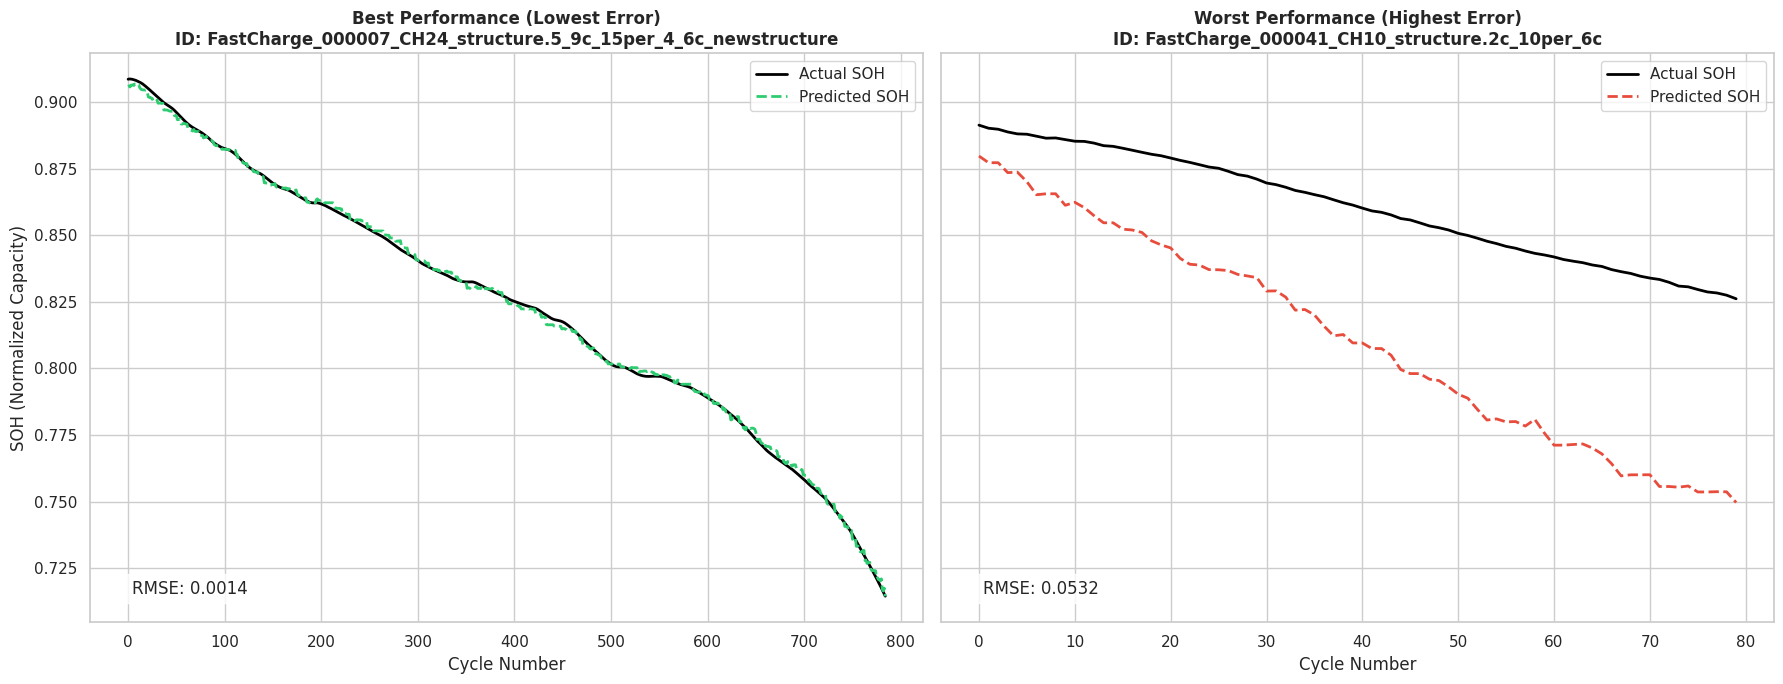

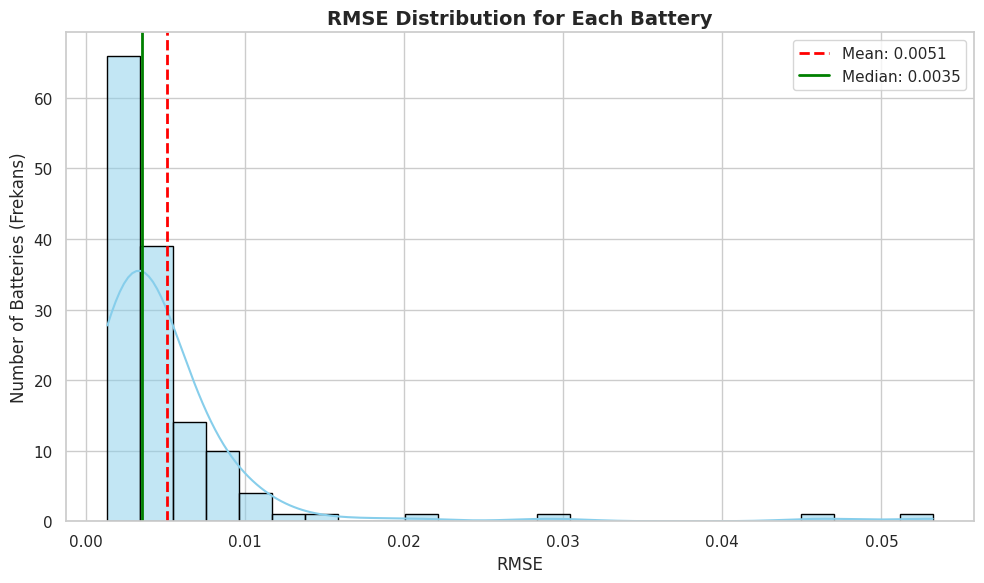

In [9]:
#Defined features,target and battery groups matrices
Features_list = []
Target_list = []
Groups_list = []

#Defined a dictionary to save individual battery errors and results
battery_errors = {}
battery_results = {}

#Opened the h5 file with features and target data 
with h5py.File("FastCharge__Features_Target.h5", "r") as h5f:
    batteries = list(h5f.keys())

    #Got the features and target data, and grouped them under same battery name
    for battery_index,battery_name in enumerate(batteries):
        features = h5f[battery_name]['Features'][:]
        target = h5f[battery_name]['Target'][:]
        
        Features_list.append(features)
        Target_list.append(target)

        num_cycles = features.shape[0]
        Groups_list.append(np.full(num_cycles, battery_index))

    #Combined all feature,target,groups values in one for each
    Features = np.vstack(Features_list)
    Target = np.concatenate(Target_list)
    Groups = np.concatenate(Groups_list)

    #Defined K-Fold Group for 5 different train-test configurations
    gkf = GroupKFold(n_splits=5)

    #Splitted the batteries with indexes gotten from K-Fold Group
    for fold, (train_index, test_index) in enumerate(gkf.split(Features, Target, Groups)):

        #Defined the Features and Target for train and test datasets
        X_train, X_test = Features[train_index], Features[test_index]
        y_train, y_test = Target[train_index], Target[test_index]

        #Built another model with pipeline for hyperparameter optimization
        opt_pipeline = Pipeline([
            ('imputer',SimpleImputer(strategy='median')),
            ('scaler',MinMaxScaler()),
            ('model',XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1))
        ])
        
        #Set hyperparameter options for grid search
        param_grid = {
            'model__n_estimators': [1500],
            'model__max_depth': [3],
            'model__gamma': [0],
            'model__reg_lambda': [0.5, 1, 5, 10],
            'model__learning_rate' : [0.1],
            'model__colsample_bytree' : [0.9, 1.0]
        }

        #Defined the grid search for optimization with GroupKFold split
        grid_search = GridSearchCV(
            estimator=opt_pipeline,
            param_grid=param_grid,
            cv=GroupKFold(n_splits=3),
            scoring='neg_mean_squared_error',
            n_jobs=-1
        )
        
        #Built another model with optimized hyperparameters and trained it
        grid_search.fit(X_train, y_train, groups=Groups[train_index])
        model = grid_search.best_estimator_

        #Did the prediction and measured error rates
        y_prediction = model.predict(X_test)
        
        #Found the unique batteries to inspect their error rates 
        test_groups = Groups[test_index]
        unique_batteries = np.unique(test_groups)
        for bat_idx in unique_batteries:
            mask = (test_groups == bat_idx)
            bat_y_true = y_test[mask]
            bat_y_pred = y_prediction[mask]
            bat_rmse = np.sqrt(mean_squared_error(bat_y_true, bat_y_pred))
            bat_name = batteries[bat_idx]
            
            #Saved the values and error rates for plotting
            battery_errors[bat_name] = bat_rmse
            battery_results[bat_name] = {
                'true': bat_y_true,
                'pred': bat_y_pred,
                'rmse': bat_rmse
            }

#Sorted the error rates and got the top 10 and bottom 10 error rates
sorted_errors = sorted(battery_errors.items(), key=lambda item: item[1])
best_10 = sorted_errors[:10]       # En düşük hatalı ilk 10
worst_10 = sorted_errors[-10:][::-1] # En yüksek hatalı son 10 (ters çevrilmiş)

#Printed the results
print(f"{'Rank':<5} | {'Best Batteries (Low Error)':<30}     | {'Worst Batteries (High Error)':<30}")
print("-" * 75)
for i in range(10):
    b_name, b_err = best_10[i]
    w_name, w_err = worst_10[i]
    print(f"#{i+1:<4} | {b_name[:25]:<25} ({b_err:.4f}) | {w_name[:25]:<25} ({w_err:.4f})")

#Found the worst and best resulted batteries
best_bat_name = best_10[0][0]
worst_bat_name = worst_10[0][0]

#Started poltting the results for both of them for comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)
sns.set_style("whitegrid")

#Set up the graph,title,axis
for i, (b_name, title, color) in enumerate([
    (best_bat_name, "Best Performance (Lowest Error)", "#2ecc71"),
    (worst_bat_name, "Worst Performance (Highest Error)", "#e74c3c")
]):
    data = battery_results[b_name]
    cycles = range(len(data['true']))
    
    axes[i].plot(cycles, data['true'], label='Actual SOH', color='black', lw=2)
    axes[i].plot(cycles, data['pred'], label='Predicted SOH', color=color, linestyle='--', lw=2)
    
    axes[i].set_title(f"{title}\nID: {b_name}", fontweight='bold')
    axes[i].set_xlabel('Cycle Number')
    axes[i].legend()
    axes[i].text(0.05, 0.05, f"RMSE: {data['rmse']:.4f}", transform=axes[i].transAxes, 
                 bbox=dict(facecolor='white', alpha=0.8))

axes[0].set_ylabel('SOH (Normalized Capacity)')

#Printed the graph
plt.tight_layout()
plt.show()

#Defined an error list
errors_list = list(battery_errors.values())

#Defined the figure and wrote histogram with density curve (KDE)
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

sns.histplot(errors_list, bins=25, kde=True, color='skyblue', edgecolor='black')

#Added statistical values (Mean and Median)
mean_val = np.mean(errors_list)
median_val = np.median(errors_list)

#Set up the graph,title,axis
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.4f}')
plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.4f}')

plt.title('RMSE Distribution for Each Battery', fontsize=14, fontweight='bold')
plt.xlabel('RMSE', fontsize=12)
plt.ylabel('Number of Batteries (Frekans)', fontsize=12)
plt.legend()

#Printed the graph
plt.tight_layout()
plt.show()

6. Aynı veri ile bir LightGBM (Light Gradient Boosting Machine) regresyon modeli eğittim, bu modele de hiperparametre optimizsayonu yaptım ve test ettim
(Trained a LightGBM (Light Gradient Boosting Machine) regressor with same data, did hyperparameter optimization for this model as well and tested it).

In [10]:
#Defined features,target and battery groups matrices
Features_list = []
Target_list = []
Groups_list = []

#Defined error rates for model statistics
fold_rmse_scores = []
fold_mae_scores = []

fold_rmse_opt_scores = []
fold_mae_opt_scores = []

#Defining matrices to collect all test and predictions for comparison later
all_y_test = []
all_y_prediction_opt = []

#Defined matrices to collect all coefficients of the model
all_fold_feature_importances = []
all_fold_opt_feature_importances = []

#Opened the h5 file with features and target data 
with h5py.File("FastCharge__Features_Target.h5", "r") as h5f:
    first_battery = list(h5f.keys())[0]
    feature_names = h5f[first_battery]['Features'].attrs['Names']
    print("Features Used in the Model:")
    print(feature_names)

    #Got the features and target data, and grouped them under same battery name
    batteries = list(h5f.keys())
    for battery_index,battery_name in enumerate(batteries):
        features = h5f[battery_name]['Features'][:]
        target = h5f[battery_name]['Target'][:]
        
        Features_list.append(features)
        Target_list.append(target)

        num_cycles = features.shape[0]
        Groups_list.append(np.full(num_cycles, battery_index))

    #Combining all feature,target,groups values in one for each
    Features = np.vstack(Features_list)
    Target = np.concatenate(Target_list)
    Groups = np.concatenate(Groups_list)

    #Defined K-Fold Group for 5 different train-test configurations
    gkf = GroupKFold(n_splits=5)

    #Splitted the batteries with indexes gotten from K-Fold Group
    for fold, (train_index, test_index) in enumerate(gkf.split(Features, Target, Groups)):
        print(f"--- FOLD {fold+1} ---")

        X_train, X_test = Features[train_index], Features[test_index]
        y_train, y_test = Target[train_index], Target[test_index]

        #Built a base model with pipeline
        base_pipeline = Pipeline([
            ('imputer',SimpleImputer(strategy='median')),
            ('scaler',MinMaxScaler()),
            ('model',LGBMRegressor(n_estimators=3500, random_state=42, n_jobs=1,verbose=-1))
        ])

        #Trained the base model for future comparison
        print("LightGBM is training...")
        model = base_pipeline.fit(X_train, y_train)
        warnings.filterwarnings("ignore", category=UserWarning)

        #Built another model with pipeline for hyperparameter optimization
        opt_pipeline = Pipeline([
            ('imputer',SimpleImputer(strategy='median')),
            ('scaler',MinMaxScaler()),
            ('model',LGBMRegressor(random_state=42, n_jobs=1,verbose=-1))
        ])

        #Set hyperparameter options for grid search
        param_grid = {
            'model__n_estimators': [3500],
            'model__num_leaves': [3,4],
            'model__max_depth': [3],
        }

        #Defined the grid search for optimization with GroupKFold split
        grid_search = GridSearchCV(
            estimator=opt_pipeline,
            param_grid=param_grid,
            cv=GroupKFold(n_splits=3),
            scoring='neg_mean_squared_error',
            n_jobs=-1
        )
        
        #Built another model with optimized hyperparameters and trained it for future comparison
        grid_search.fit(X_train, y_train, groups=Groups[train_index])
        model_opt = grid_search.best_estimator_
        print(f"Best parameters: {grid_search.best_params_}")
        
        #Inspected the feature importances
        feature_importances = model[-1].feature_importances_
        opt_feature_importances = model_opt[-1].feature_importances_
        print("Feature Importances:", np.round(feature_importances, 4))
        print("Feature Importances:", np.round(opt_feature_importances, 4))

        #Filled matrices with coefficients for later
        all_fold_feature_importances.append(feature_importances)
        all_fold_opt_feature_importances.append(opt_feature_importances)

        #Did the prediction and calculated the error rates
        y_prediction = model.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, y_prediction))
        mae = mean_absolute_error(y_test, y_prediction)

        y_prediction_opt = model_opt.predict(X_test)
        rmse_opt = np.sqrt(mean_squared_error(y_test, y_prediction_opt))
        mae_opt = mean_absolute_error(y_test, y_prediction_opt)
        
        #Added error rates to the matrices
        fold_rmse_scores.append(rmse)
        fold_mae_scores.append(mae)

        fold_rmse_opt_scores.append(rmse_opt)
        fold_mae_opt_scores.append(mae_opt)

        #Filled matrices with test and predictions for comparison later
        all_y_test.extend(y_test)
        all_y_prediction_opt.extend(y_prediction_opt)
                
        print(f"RMSE           : {rmse:.4f} | MAE           : {mae:.4f}")
        print(f"RMSE(Optimized): {rmse_opt:.4f} | MAE(Optimized): {mae_opt:.4f}")

    #Calculating mean and std values of each coefficient
    mean_feature_importances = np.mean(all_fold_feature_importances, axis=0)
    mean_opt_feature_importances = np.mean(all_fold_opt_feature_importances, axis=0)
    std_opt_feature_importances = np.std(all_fold_opt_feature_importances, axis=0)
        
    #Printed the results
    print("\n" + "="*50)
    print("LIGHTGBM REGRESSOR 5-FOLD ERROR RATE RESULTS:")
    print(f"Mean RMSE           : {np.mean(fold_rmse_scores):.4f}")
    print(f"Mean MAE            : {np.mean(fold_mae_scores):.4f}")
    print(f"Mean RMSE(Optimized): {np.mean(fold_rmse_opt_scores):.4f}")
    print(f"Mean MAE(Optimized) : {np.mean(fold_mae_opt_scores):.4f}")

Features Used in the Model:
['Internal_Resistance' 'Temperature_Variance' 'dQ/dV_Kurtosis'
 'dQ/dV_Skewness' 'dQ/dV_Peakheight' 'dQ/dV_Variance_log']
--- FOLD 1 ---
LightGBM is training...
Best parameters: {'model__max_depth': 3, 'model__n_estimators': 3500, 'model__num_leaves': 4}
Feature Importances: [17487 18408 15582 19085 14714 19724]
Feature Importances: [1823 1371 1814 2088 1160 2244]
RMSE           : 0.0053 | MAE           : 0.0036
RMSE(Optimized): 0.0052 | MAE(Optimized): 0.0034
--- FOLD 2 ---
LightGBM is training...
Best parameters: {'model__max_depth': 3, 'model__n_estimators': 3500, 'model__num_leaves': 4}
Feature Importances: [17801 18046 15424 18421 14996 20312]
Feature Importances: [1686 1351 1808 2226 1222 2207]
RMSE           : 0.0047 | MAE           : 0.0033
RMSE(Optimized): 0.0041 | MAE(Optimized): 0.0028
--- FOLD 3 ---
LightGBM is training...
Best parameters: {'model__max_depth': 3, 'model__n_estimators': 3500, 'model__num_leaves': 4}
Feature Importances: [17117 182

7. Bu modelin de optimizasyon sonrası tüm train-test konfigürasyonlarının sonuçlarını kullanarak grafikler çizdirdim
(Plotted graphs with the results from all train-test configurations of this model as well after optimization).

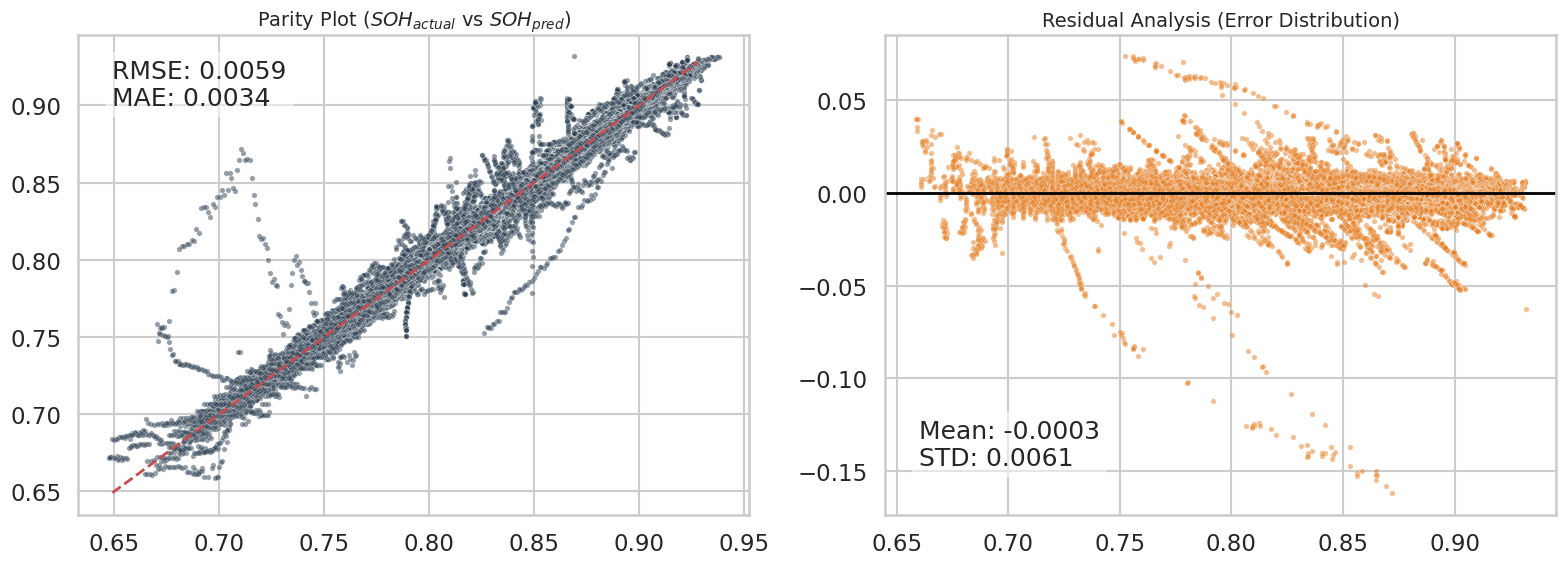

In [11]:
#Set the seaborn theme
sns.set_theme(style="whitegrid", context="talk")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#Plotted the parity(Real vs Predicted)
sns.scatterplot(x=all_y_test, y=all_y_prediction_opt, alpha=0.5, color="#2c3e50", s=15, ax=axes[0])
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title(r'Parity Plot ($SOH_{actual}$ vs $SOH_{pred}$)', fontsize=14)


#Plotted the residuals ()
residuals = np.array(all_y_test) - np.array(all_y_prediction_opt)
sns.scatterplot(x=all_y_prediction_opt, y=residuals, alpha=0.5, color="#e67e22", s=15, ax=axes[1])
axes[1].axhline(0, color='black', linestyle='-', lw=2)
axes[1].set_title('Residual Analysis (Error Distribution)', fontsize=14)
axes[0].text(0.05, 0.95, f'RMSE: {np.mean(fold_rmse_opt_scores):.4f}\nMAE: {np.mean(fold_mae_opt_scores):.4f}',
transform=axes[0].transAxes, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))
axes[1].text(0.05, 0.2, f'Mean: {np.mean(residuals):.4f}\nSTD: {np.std(residuals):.4f}', 
transform=axes[1].transAxes, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))

#Printed the graph
plt.tight_layout()
plt.show()

8. Hiperparametre optimizasyonu öncesi ve sonrası LightGBM modelinin de öznitelik önemlerini karşılaştırdım
(Compared the feature importances of the LightGBM model for before-after hyperparameter optimization as well).

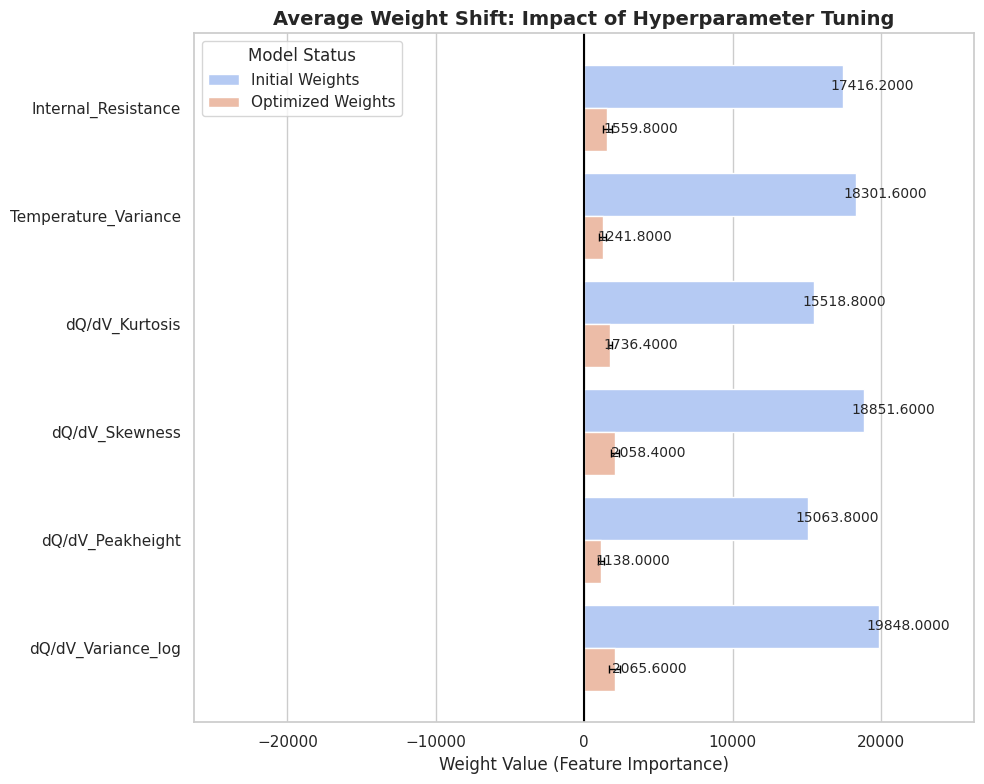

In [12]:
#Defined the coefficient data for features
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Initial Weights': mean_feature_importances,
    'Optimized Weights': mean_opt_feature_importances
}).melt(id_vars='Feature', var_name='Model Status', value_name='Weight Value')

#Defined the size of the plot
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

#Plotted a bar graph
ax = sns.barplot(
    data=coef_df, 
    y='Feature',      
    x='Weight Value', 
    hue='Model Status', 
    palette='coolwarm'
)

#Adjusted the graph for small values
max_val = coef_df['Weight Value'].abs().max()
max_std = np.max(std_opt_feature_importances)
plt.xlim(-(max_val + max_std) * 1.3, (max_val + max_std) * 1.3) 

#Set up the title and labels
plt.title('Average Weight Shift: Impact of Hyperparameter Tuning', fontweight='bold', fontsize=14)
plt.xlabel('Weight Value (Feature Importance)', fontsize=12)
plt.ylabel('') 
plt.axvline(0, color='black', lw=1.5) 

#Wrote the coefficient values on the graph
for i, p in enumerate(ax.patches):
    width = p.get_width()
    if abs(width) > 1e-6:
        #Calculated the offset to avoid overlap with error bars
        feature_idx = i % len(feature_names)
        current_std = std_opt_feature_importances[feature_idx] if i >= len(feature_names) else 0
        text_offset = current_std + (max_val * 0.1)
        
        ax.annotate(f'{width:.4f}', 
                    (width + (text_offset if width > 0 else -text_offset), p.get_y() + p.get_height() / 2.),
                    ha = 'center', va = 'center', 
                    fontsize=10)
        
        #Added error bars for Optimized Weights and defined a label for legend
        if i >= len(feature_names): 
            eb = plt.errorbar(
                x=width, 
                y=p.get_y() + p.get_height() / 2., 
                xerr=current_std, 
                fmt='none', c='black', capsize=3, elinewidth=1,
                label='Cross-Val Std. Dev.' if i == len(ax.patches)-1 else ""
            )

#Printed the graph
plt.legend(title='Model Status', loc='best')
plt.tight_layout()
plt.show()

9. Batalyalar özelinde LightGBM modelinin de hata oranlarını hesapladım, en yüksek ve en düşük hata oranına sahip piller için model performansını grafiklerle karşılaştırdım
(Calculated the error rates or LightGBM model for individual batteries as well, compared the model performance with graphics on batteries with highest and lowest error rates).

Rank  | Best Batteries (Low Error)         | Worst Batteries (High Error)  
---------------------------------------------------------------------------
#1    | FastCharge_000007_CH24_st (0.0012) | FastCharge_000041_CH10_st (0.0519)
#2    | FastCharge_000065_CH33_st (0.0014) | FastCharge_000052_CH41_st (0.0475)
#3    | FastCharge_000015_CH4_str (0.0014) | FastCharge_000035_CH12_st (0.0264)
#4    | FastCharge_000066_CH25_st (0.0015) | FastCharge_000017_CH46_st (0.0158)
#5    | FastCharge_000013_CH13_st (0.0015) | FastCharge_000017_CH41_st (0.0114)
#6    | FastCharge_000006_CH11_st (0.0016) | FastCharge_000055_CH20_st (0.0103)
#7    | FastCharge_000012_CH21_st (0.0016) | FastCharge_000024_CH45_st (0.0101)
#8    | FastCharge_000012_CH29_st (0.0017) | FastCharge_000004_CH3_str (0.0099)
#9    | FastCharge_000014_CH24_st (0.0017) | FastCharge_000021_CH28_st (0.0095)
#10   | FastCharge_000050_CH40_st (0.0017) | FastCharge_000032_CH22_st (0.0094)


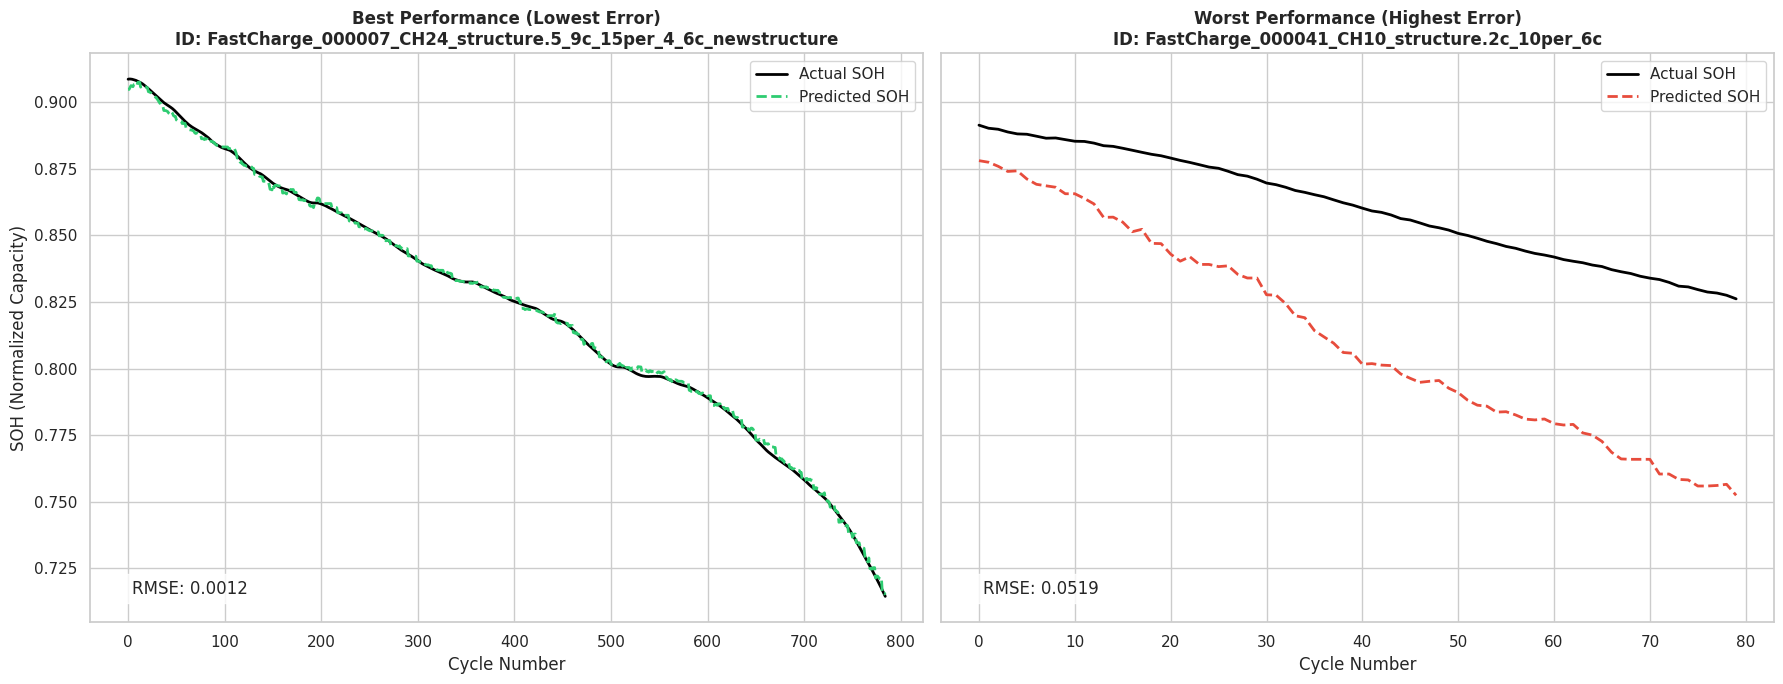

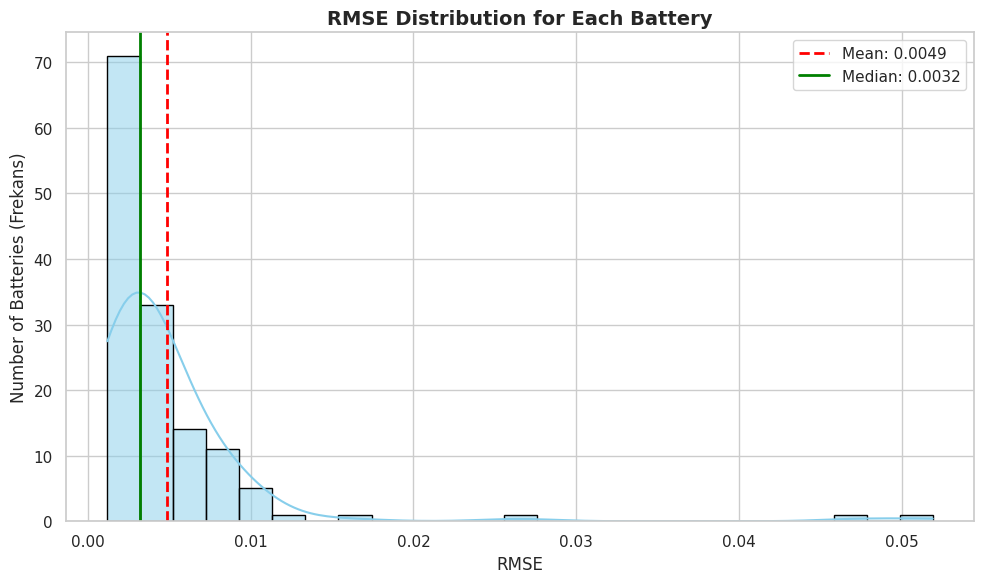

In [13]:
#Defined features,target and battery groups matrices
Features_list = []
Target_list = []
Groups_list = []

#Defined a dictionary to save individual battery errors and results
battery_errors = {}
battery_results = {}

#Opened the h5 file with features and target data 
with h5py.File("FastCharge__Features_Target.h5", "r") as h5f:
    batteries = list(h5f.keys())

    #Got the features and target data, and grouped them under same battery name
    for battery_index,battery_name in enumerate(batteries):
        features = h5f[battery_name]['Features'][:]
        target = h5f[battery_name]['Target'][:]
        
        Features_list.append(features)
        Target_list.append(target)

        num_cycles = features.shape[0]
        Groups_list.append(np.full(num_cycles, battery_index))

    #Combined all feature,target,groups values in one for each
    Features = np.vstack(Features_list)
    Target = np.concatenate(Target_list)
    Groups = np.concatenate(Groups_list)

    #Defined K-Fold Group for 5 different train-test configurations
    gkf = GroupKFold(n_splits=5)

    #Splitted the batteries with indexes gotten from K-Fold Group
    for fold, (train_index, test_index) in enumerate(gkf.split(Features, Target, Groups)):

        #Defined the Features and Target for train and test datasets
        X_train, X_test = Features[train_index], Features[test_index]
        y_train, y_test = Target[train_index], Target[test_index]

        #Built another model with pipeline for hyperparameter optimization
        opt_pipeline = Pipeline([
            ('imputer',SimpleImputer(strategy='median')),
            ('scaler',MinMaxScaler()),
            ('model',LGBMRegressor(random_state=42, n_jobs=1,verbose=-1))
        ])
        
        #Set hyperparameter options for grid search
        param_grid = {
            'model__n_estimators': [3500],
            'model__num_leaves': [3,4],
            'model__max_depth': [3],
        }

        #Defined the grid search for optimization with GroupKFold split
        grid_search = GridSearchCV(
            estimator=opt_pipeline,
            param_grid=param_grid,
            cv=GroupKFold(n_splits=3),
            scoring='neg_mean_squared_error',
            n_jobs=-1
        )
        
        #Built another model with optimized hyperparameters and trained it
        grid_search.fit(X_train, y_train, groups=Groups[train_index])
        model = grid_search.best_estimator_

        #Did the prediction and measured error rates
        y_prediction = model.predict(X_test)
        
        #Found the unique batteries to inspect their error rates 
        test_groups = Groups[test_index]
        unique_batteries = np.unique(test_groups)
        for bat_idx in unique_batteries:
            mask = (test_groups == bat_idx)
            bat_y_true = y_test[mask]
            bat_y_pred = y_prediction[mask]
            bat_rmse = np.sqrt(mean_squared_error(bat_y_true, bat_y_pred))
            bat_name = batteries[bat_idx]
            
            #Saved the values and error rates for plotting
            battery_errors[bat_name] = bat_rmse
            battery_results[bat_name] = {
                'true': bat_y_true,
                'pred': bat_y_pred,
                'rmse': bat_rmse
            }

#Sorted the error rates and got the top 10 and bottom 10 error rates
sorted_errors = sorted(battery_errors.items(), key=lambda item: item[1])
best_10 = sorted_errors[:10]       # En düşük hatalı ilk 10
worst_10 = sorted_errors[-10:][::-1] # En yüksek hatalı son 10 (ters çevrilmiş)

#Printed the results
print(f"{'Rank':<5} | {'Best Batteries (Low Error)':<30}     | {'Worst Batteries (High Error)':<30}")
print("-" * 75)
for i in range(10):
    b_name, b_err = best_10[i]
    w_name, w_err = worst_10[i]
    print(f"#{i+1:<4} | {b_name[:25]:<25} ({b_err:.4f}) | {w_name[:25]:<25} ({w_err:.4f})")

#Found the worst and best resulted batteries
best_bat_name = best_10[0][0]
worst_bat_name = worst_10[0][0]

#Started poltting the results for both of them for comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)
sns.set_style("whitegrid")

#Set up the graph,title,axis
for i, (b_name, title, color) in enumerate([
    (best_bat_name, "Best Performance (Lowest Error)", "#2ecc71"),
    (worst_bat_name, "Worst Performance (Highest Error)", "#e74c3c")
]):
    data = battery_results[b_name]
    cycles = range(len(data['true']))
    
    axes[i].plot(cycles, data['true'], label='Actual SOH', color='black', lw=2)
    axes[i].plot(cycles, data['pred'], label='Predicted SOH', color=color, linestyle='--', lw=2)
    
    axes[i].set_title(f"{title}\nID: {b_name}", fontweight='bold')
    axes[i].set_xlabel('Cycle Number')
    axes[i].legend()
    axes[i].text(0.05, 0.05, f"RMSE: {data['rmse']:.4f}", transform=axes[i].transAxes, 
                 bbox=dict(facecolor='white', alpha=0.8))

axes[0].set_ylabel('SOH (Normalized Capacity)')

#Printed the graph
plt.tight_layout()
plt.show()

#Defined an error list
errors_list = list(battery_errors.values())

#Defined the figure and wrote histogram with density curve (KDE)
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

sns.histplot(errors_list, bins=25, kde=True, color='skyblue', edgecolor='black')

#Added statistical values (Mean and Median)
mean_val = np.mean(errors_list)
median_val = np.median(errors_list)

#Set up the graph,title,axis
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.4f}')
plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.4f}')

plt.title('RMSE Distribution for Each Battery', fontsize=14, fontweight='bold')
plt.xlabel('RMSE', fontsize=12)
plt.ylabel('Number of Batteries (Frekans)', fontsize=12)
plt.legend()

#Printed the graph
plt.tight_layout()
plt.show()